# Lab 3: Sentinel-1 Time Series for Crop Growth in Midwest Row-Crop Fields

This notebook is for a lab on seasonal crop growth using Sentinel-1 SAR backscatter in large Midwestern U.S. fields.

The lab is designed to stay fully in Google Earth Engine + Python. We will be:

- building a consistent Sentinel-1 time series,
- selecting individual row-crop fields, forested regions, and towns/cities,
- extracting field-scale backscatter statistics,
- comparing seasonal trajectories,
- proposing a simple crop growth metric based on VV, VH, or VV/VH.

---

## Lab concept

Students will:

1. choose several individual regions in a Midwest US AOI. You do not have to choose a midwest US AOI, but it will be the easiest. Midwest US/Canada has perfectly North/South Aligned farms in 1.5 km grids, which uniformly grow corn/wheat/soy/etc. European farms are much smaller, and randomly oriented. Averaging over an entire field will increase the signal to noise ratio.
2. define field polygons as regions of interest,
3. build a seasonal Sentinel-1 time series,
4. compute field-level summary statistics for:
   - VV
   - VH
   - VV - VH (in dB is a convenient proxy related to VV/VH ratio)
5. interpret how those quantities evolve from:
   - bare ground / early season
   - vegetative growth
   - maturity
   - senescence (interesting fact - senescence progression is monitored via NDVI)
   - harvest

---

## Why the Midwest U.S.?

This is a good teaching region because many fields are:

- large,
- homogeneous,
- easy to outline,
- minimally affected by complex topography,
- dominated by row crops with strong seasonal structure.

That makes field-scale SAR time series much easier to interpret than small, irregular fields. Irregularly oriented fields produce an additional complexity with regards to geometry. You may have noticed when exploring Krakow SAR that the backscatter from farms could vary greatly. This can be due to differences in crop type, but it can also be related to how the rows are oriented with respect to the satellite look direction. Think about the ground texture of farms, there are many small ridges and valleys. If these ridges and valleys are parallel to the satellite look direction, backscatter will be weaker, and if the ridges and valleys are perpendicular to the satellite look direction, backscatter will be stronger.

---

## learning goals

By the end of this lab, students should be able to:

- explain why SAR time series must be filtered consistently,
- compute a field-averaged VV and VH time series,
- compare crop fields with a non-crop control,
- propose and defend simple crop growth metrics,
- explain why VH or VV-VH may respond differently from VV alone.

---

## 1. Imports and Earth Engine initialization

This notebook assumes that students already have:

- a working Python environment,
- the Earth Engine Python API,
- `geemap`,
- libraries `matplotlib` and `pandas`.

In [2]:
import ee
import geemap
import pandas as pd
import json
import matplotlib.pyplot as plt

PROJECT_ID = "ee-macioukos"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized.")

Earth Engine initialized.


## 2. Define an agricultural AOI

This notebook starts with a large AOI in northern Iowa / southern Minnesota.  
You can adjust it later, but it is helpful to begin with a region dominated by large row-crop fields. In one scene, I want you to find a place that has:

- individual crop fields that you can isolate
- A city or town that we're not expecting a strong vegetative growth signal from
- a stand of trees you can isolate

**QUESTION (5pts): Why is the subregion you chose a good choice for exploring crop growth? Trees and crops both have vegetative growth during summer months, but what differences would you expect to see over a year, with regards to VV, VH, and VV-VH? What do you expect to see in the city or town that you have isolated?**

**ANSWER:**

Region is a good choice for expolring crop growth because fields are large and regular. 

winter:

crops - low VV and VH, VV-VH high, 

trees - mid level VV and VH

spring:

crops - VV and VH increasing

trees - same as during winter

summer: 

crops - big VH, VV-VH is low

trees - VH incerased 

autumn:

crops - after harvest return to winter level VV and VH

trees - VH stable

Cities have stable VV and VV-VH because there arent as many structural  changes in them thruoght the year. 

In [ ]:
# Example AOI: large row-crop region in northern Iowa / southern Minnesota
aoi = ee.Geometry.Rectangle([-93.48, 43.90, -92.98, 44.26])

# Growing season year
YEAR = 2025

# Visualization parameters
vv_vis = {"min": -18, "max": 2}
vh_vis = {"min": -28, "max": -8}
ratio_vis = {"min": 2, "max": 12}

m = geemap.Map(center=[44.08, -93.23], zoom=11)
m.addLayer(aoi, {"color": "red"}, "AOI")
m

Map(center=[44.08, -93.23], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## 3. Helper functions

To keep the notebook readable, the repetitive Earth Engine logic is collected into helper functions.

These functions do most of the work for:

- building a filtered Sentinel-1 collection,
- creating monthly composites,
- computing a convenient VV-VH metric,
- extracting region statistics through time.

---

### Why use `VV - VH` here?

Sentinel-1 GRD backscatter in Earth Engine is in dB.  
So for this lab, instead of using a raw linear ratio `VV/VH`, we use:

\[
VV - VH
\]

because in dB space this is directly related to the log-ratio and is easier to interpret consistently alongside VV and VH.


In [5]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass="ASCENDING",
                      mode="IW",
                      resolution=10):
    """Return a filtered Sentinel-1 GRD collection with VV and VH."""
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", mode))
        .filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
        .filter(ee.Filter.eq("resolution_meters", resolution))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
    )
    return collection


def monthly_composite(year, month, region=aoi):
    """Return a monthly median Sentinel-1 image with a derived VV-VH band."""
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    collection = get_s1_collection(start, end, region=region)
    image = collection.median().clip(region)

    vv_minus_vh = image.select("VV").subtract(image.select("VH")).rename("VV_minus_VH")

    return (
        image.addBands(vv_minus_vh)
        .set({
            "year": year,
            "month": month,
            "system:time_start": start.millis(),
            "scene_count": collection.size()
        })
    )


def build_monthly_stack(year, months=range(3, 11), region=aoi):
    """Create a monthly ImageCollection for a growing season."""
    images = [monthly_composite(year, month, region=region) for month in months]
    return ee.ImageCollection(images)


def region_time_series(image_collection, region, scale=10):
    """Extract field-level mean VV, VH, and VV_minus_VH through time.

    Accepts either an ee.Geometry or an ee.Feature.
    """
    # If region is a Feature, convert it to its geometry
    if isinstance(region, ee.feature.Feature):
        region = region.geometry()

    def per_image(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=scale,
            maxPixels=1e9,
            bestEffort=True
        )
        return ee.Feature(None, {
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            "year": img.get("year"),
            "month": img.get("month"),
            "scene_count": img.get("scene_count"),
            "VV": stats.get("VV"),
            "VH": stats.get("VH"),
            "VV_minus_VH": stats.get("VV_minus_VH")
        })

    return ee.FeatureCollection(image_collection.map(per_image))

def fc_to_df(fc):
    """Convert an Earth Engine FeatureCollection of stats into a pandas DataFrame."""
    data = fc.getInfo()["features"]
    rows = [f["properties"] for f in data]
    df = pd.DataFrame(rows)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date").reset_index(drop=True)
    return df


## 4. Build a seasonal Sentinel-1 time series

We build monthly median images from February through November.

**QUESTION (5pts): What are the advantages and disadvantages of using monthly median stacks instead of relying on single scenes? In what circumstances would you not want to do any temporal averaging, and instead rely on single scenes?**

Advantages:

median smooths out the noise

each pass might miss out on part of the AOI, so another one is good to cover the missing part

disadvantages:

rapid crop growth might lead to information blur during averaging

if there arent many updates over the AOI (sample size of 2 images per month), then it isnt really better than a single scene

**ANSWER:**

**QUESTION (5pts): Why do we filter Sentinel-1 by orbit direction, instrument mode, polarization, and resolution before building the time series? What might happen if ascending and descending passes were mixed in the same time series?**

**ANSWER:**

Every image in a time series must be measuring the same area in the smae way. Otherwise the backscatter does not precisely reflects what is happening on the surface.

In [6]:
months = list(range(2, 12))  # February through November
monthly_stack = build_monthly_stack(YEAR, months=months, region=aoi)

print("Monthly images in stack:", monthly_stack.size().getInfo())

# Check how many scenes contribute to each month
for month in months:
    img = monthly_composite(YEAR, month, aoi)
    print(f"Month {month:02d}: {ee.Number(img.get('scene_count')).getInfo()} scenes")


Monthly images in stack: 10
Month 02: 5 scenes
Month 03: 6 scenes
Month 04: 7 scenes
Month 05: 4 scenes
Month 06: 3 scenes
Month 07: 3 scenes
Month 08: 4 scenes
Month 09: 2 scenes
Month 10: 4 scenes
Month 11: 4 scenes


## 5. Quick visual inspection

Before drawing fields, it is useful to inspect one or two monthly composites.

Suggested things to look for:

- field texture,
- strong contrasts between different fields,
- stable non-crop controls such as roads, towns, or tree patches.

**QUESTION (10pts): Compare an early month with a peak month visually. Feel free to change the months plotted, or add in comparisons of early vs mid- season VV_minus_VH, for your investigations. Take particular note of how much VH changes vs how much VV changes. What regions do you think you will choose for your ROI's and why? If you want an extra challenge (but not necessary), try to find a field you think was tall crops, a field you think was short crops, and a field you think was left barren.**

**ANSWER:**

Early month fields are very dark, due to reflectance of bare soil. Later after the crops are grown and are denser in volume, fields are brighter and are even distinguishable beetween each other. After observation the gretaer contrast is in VH which means it changes more drastically than VV. For my AOI i will choose one very bright field, gray and darker one to hopefully see clear differences.

In [7]:
img_early = monthly_composite(YEAR, 2, aoi)
img_peak = monthly_composite(YEAR, 7, aoi)

#YOUR CODE HERE: The lines above grab the montlhy composite images for February and July. I want you to plot a split_map image of the VH channel in this cell, and in the cell below plot a split_map image of the VV channel for the same months.
m = geemap.Map(center=[44.08, -93.23], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VH"), vh_vis, "VH February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VH"), vh_vis, "VH July")
)
display(m)
#m.addLayer(aoi, {"color": "red"}, "AOI")

Map(center=[44.08, -93.23], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

In [8]:
#Plot the VV split_map here.

m = geemap.Map(center=[44.08, -93.23], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VV"), vv_vis, "VV February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VV"), vv_vis, "VV July")
)
display(m)

Map(center=[44.08, -93.23], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

# 6. Draw field polygons

Use the map drawing tools to create several polygons:

- at least **two different crop fields**
- at least **two control areas** (1 patch of trees, 1 city or town)

### Suggested strategy
Pick fields that are:

- large,
- internally uniform,
- clearly separated from neighboring fields.

After drawing polygons on the map, export them to Earth Engine objects.

**NOTE: You will need to remember the order of the ROI's you chose. For example, remember that you first chose three farm fields, then a tree stand, then the city/town. In the next section, you will need to assign these drawn features to variables and a dictionary.**



In [13]:
m = geemap.Map(center=[44.08, -93.23], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
m.addLayer(img_peak.select("VH"), vh_vis, "VH July")


Field_1 = ee.Geometry.Rectangle(
    [-93.036346, 44.175217, -93.02609, 44.182296]
)

Field_2 = ee.Geometry.Rectangle(
    [-93.0966, 44.17531, -93.0863, 44.181835]
)

Field_3 = ee.Geometry.Rectangle(
    [-93.179512, 44.164474, -93.176422, 44.171001]
)

Trees_1 = ee.Geometry.Rectangle(
    [-93.401299, 44.083763, -93.398724, 44.085612]
)

Control_1 = ee.Geometry.Rectangle(
    [-93.25573, 44.086352, -93.245945, 44.093873]
)

m.addLayer(Field_1, {"color": "red"}, "Field_1")
m.addLayer(Field_2, {"color": "blue"}, "Field_2")
m.addLayer(Field_3, {"color": "green"}, "Field_3")
m.addLayer(Trees_1, {"color": "yellow"}, "Trees_1")
m.addLayer(Control_1, {"color": "purple"}, "Control_1")

#m.addLayer(aoi, {"color": "red"}, "AOI")
m

# After drawing polygons with the map tools, use:
# drawn_fc = m.draw_features

Map(center=[44.08, -93.23], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [10]:
drawn_fc = m.draw_features
print(drawn_fc)

[<ee.feature.Feature object at 0x7f4bdb936210>, <ee.feature.Feature object at 0x7f4bdb92a850>, <ee.feature.Feature object at 0x7f4bdb8e8290>, <ee.feature.Feature object at 0x7f4bdb8a1050>, <ee.feature.Feature object at 0x7f4bdb8a3990>]


## 7. Make sure your drawn features are where you want them.

To do this, you will need to need to adjust the code below to match the order and number of ROI's you chose to investigate.


In [ ]:
# Example fallback polygons
#field_1 = ee.Geometry.Rectangle([-93.731, 43.949, -93.714, 43.964])
#field_2 = ee.Geometry.Rectangle([-93.666, 43.865, -93.646, 43.882])
#control_1 = ee.Geometry.Rectangle([-93.585, 43.971, -93.571, 43.982])  # mixed non-crop / built area
field_1 = drawn_fc[0]
field_2 = drawn_fc[1]
field_3 = drawn_fc[2]
trees_1 = drawn_fc[3]
control_1 = drawn_fc[4]
roi_dict = {
    "Field_1": field_1,
    "Field_2": field_2,
    "Field_3": field_3,
    "Trees_1": trees_1,
    "Control_1": control_1
}

m = geemap.Map(center=[44.8, -93.23], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)
m

##PLEASE PASTE THE OUTPUT OF THIS AS A COMMENT HERE SO THAT I KNOW WHICH ROI's YOU CHOSE
for name, roi in roi_dict.items():
    print(name, roi.geometry().getInfo())


Field_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.036346, 44.175217], [-93.036346, 44.182296], [-93.02609, 44.182296], [-93.02609, 44.175217], [-93.036346, 44.175217]]]}
Field_2 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.0966, 44.17531], [-93.0966, 44.181835], [-93.0863, 44.181835], [-93.0863, 44.17531], [-93.0966, 44.17531]]]}
Field_3 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.179512, 44.164474], [-93.179512, 44.171001], [-93.176422, 44.171001], [-93.176422, 44.164474], [-93.179512, 44.164474]]]}
Trees_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.401299, 44.083763], [-93.401299, 44.085612], [-93.398724, 44.085612], [-93.398724, 44.083763], [-93.401299, 44.083763]]]}
Control_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.25573, 44.086352], [-93.25573, 44.093873], [-93.245945, 44.093873], [-93.245945, 44.086352], [-93.25573, 44.086352]]]}


## 8. Extract time series for each field

For each ROI, compute a field-mean time series of:

- VV
- VH
- VV - VH

This is the core analysis step of the lab.

In [12]:
ts_dict = {}

for name, geom in roi_dict.items():
    fc = region_time_series(monthly_stack, geom, scale=10)
    df = fc_to_df(fc)
    ts_dict[name] = df

ts_dict["Field_1"]


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-29.725835,-14.877989,14.847845,2025-02-01,2,5,2025
1,-18.681965,-8.756769,9.925196,2025-03-01,3,6,2025
2,-22.549819,-11.254464,11.295355,2025-04-01,4,7,2025
3,-24.440062,-13.038152,11.401909,2025-05-01,5,4,2025
4,-22.628062,-12.453880,10.174182,2025-06-01,6,3,2025
5,-13.812345,-9.028836,4.783508,2025-07-01,7,3,2025
6,-16.734646,-10.022394,6.712252,2025-08-01,8,4,2025
7,-16.450342,-10.467196,5.983146,2025-09-01,9,2,2025
8,-15.657311,-10.535253,5.122058,2025-10-01,10,4,2025
9,-20.570545,-12.055893,8.514653,2025-11-01,11,4,2025


**QUESTION (5pts): Which month has the minimum VH? Which month has the maximum VH? Does this match what you expected from the image comparison?**

**ANSWER:**

Minimum VH - February 
Maximum VH - July

It matches from image comaprison, VH very dark in Feb and much brigghter in July


## 9. Plot VV, VH, and VV-VH through time

These plots are where the crop-growth story should begin to emerge.

**QUESTION (20pts):**
- Qualitatively compare your three different types of ROI's (1) farms; (2) trees; and (3) towns. A few sentences to a short paragraph is enough.
- Based on these plots, identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested.
- Does VV-VH separate crops from control AOI's better than VV alone?
- Which ROI looks least like an actively growing crop field?
- Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time? Explain whether each behavior is more consistent with crop growth, forest canopy, or built-up land.

**ANSWER:**

1. - VV and VH for crop fields show change beetween each month, peak in July/August and then back to low values. VV-VH high in winter and minial in July/August
- Trees have higher and stable VH and VV aswell as VV-VH
- City AOI has high and constant VV, VH is also constant but lower than VV, VV-VH is high and has flat plot

2. Start of growth of plants - April/May - noticable increase in VH. Growth stops in July VH at maximum, VV-VH minimal. Harvest in September - drop in both VH and VV.

3. Yes, both trees and city have flatter structure all year round but crops differentiate heavily beetween each month.

4. City - stable indicators throught the year.

5. Field 1 - it was the brightest on the imagery so it is expected to have biggest differences on a monthly basis.

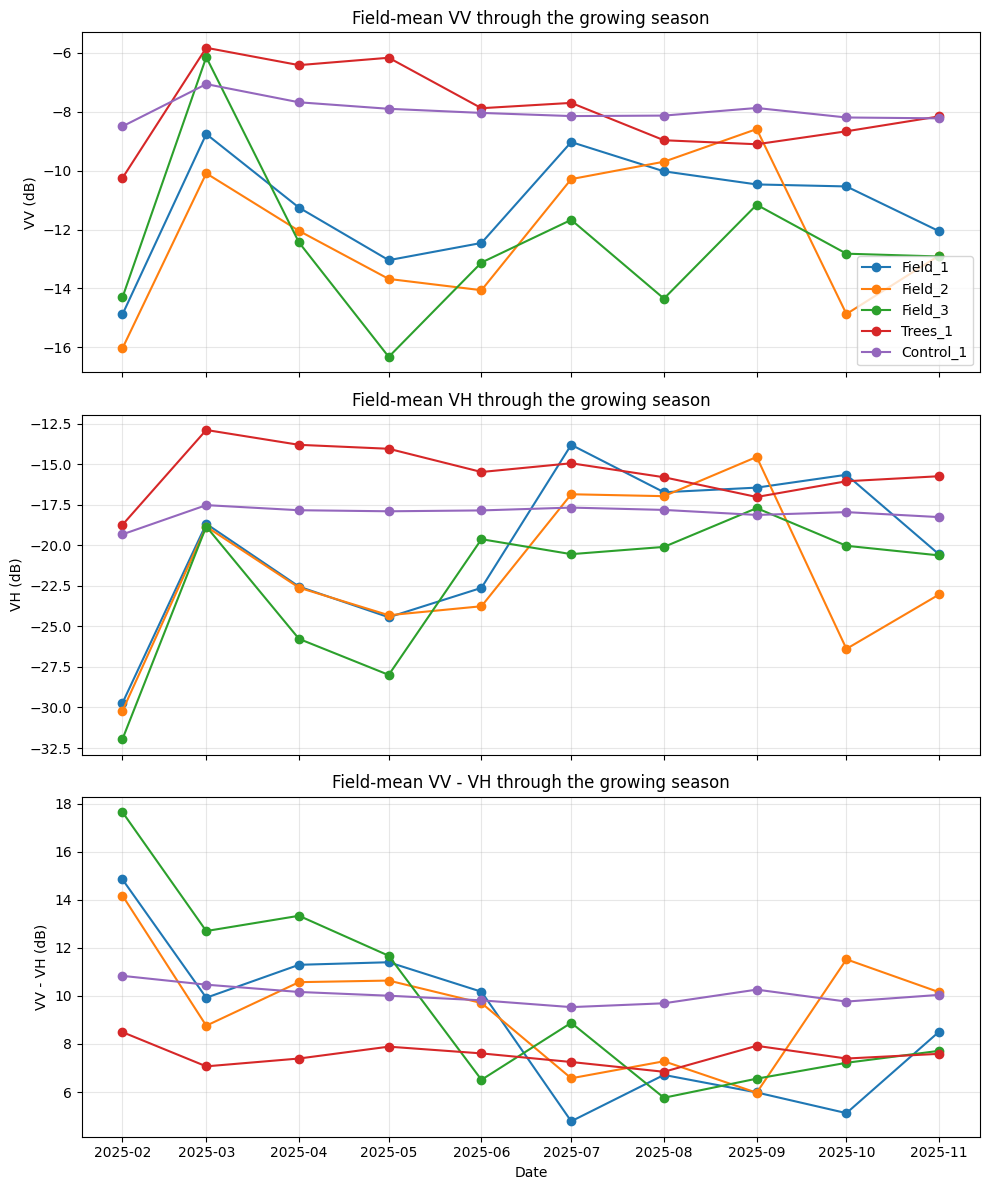

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for name, df in ts_dict.items():
    axes[0].plot(df["date"], df["VV"], marker="o", label=name)
    axes[1].plot(df["date"], df["VH"], marker="o", label=name)
    axes[2].plot(df["date"], df["VV_minus_VH"], marker="o", label=name)

axes[0].set_title("Field-mean VV through the growing season")
axes[0].set_ylabel("VV (dB)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Field-mean VH through the growing season")
axes[1].set_ylabel("VH (dB)")
axes[1].grid(True, alpha=0.3)

axes[2].set_title("Field-mean VV - VH through the growing season")
axes[2].set_ylabel("VV - VH (dB)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()


## 10. Build a simple crop-growth metric

Next I want you to propose a metric that captures crop development.

Possible first ideas include:

- peak VH minus spring VH,
- July VH minus April VH,
- maximum seasonal VV-VH range,
- cumulative increase from planting to peak growth.

Below is one simple example:

\[
Growth Metric = VH_{peak} - VH_{early}
\]

This is not necessarily the best metric — it is just a starting point.



In [15]:
##YOUR CODE HERE (50pts)
import numpy as np

def harmonic_mean(values):
    values = np.array(values)

    values = np.maximum(values, 1e-6)

    return len(values) / np.sum(1.0 / values)


def compute_growth_metrics(df):

    df = df.sort_values("month")

    spring = df[df["month"].between(3, 5)]["VH"].mean()
    april = df[df["month"] == 4]["VH"].mean()
    july = df[df["month"] == 7]["VH"].mean()
    peak = df["VH"].max()

    m1 = peak - spring
    m2 = july - april
    m3 = df["VV_minus_VH"].max() - df["VV_minus_VH"].min()

    vh_diff = df["VH"].diff().fillna(0)
    m4 = vh_diff[vh_diff > 0].sum()

    return [m1, m2, m3, m4]


def harmonic_crop_growth_metric(df):
    metrics = compute_growth_metrics(df)

    metrics = np.array(metrics)
    metrics = np.maximum(metrics, 1e-6)

    return harmonic_mean(metrics)

harmonic_growth = {}

for name, df in ts_dict.items():
    harmonic_growth[name] = harmonic_crop_growth_metric(df)

harmonic_growth

{'Field_1': np.float64(10.483353911686557),
 'Field_2': np.float64(8.474874787350098),
 'Field_3': np.float64(8.494818891871285),
 'Trees_1': np.float64(3.999991264271154e-06),
 'Control_1': np.float64(0.3417649356110944)}

## 11. Optional: compare fields spatially for one month

It is often useful to look at the mapped field values in the month of strongest contrast.

This can help connect your field-average statistics back to the actual imagery.


In [18]:
img_july = monthly_composite(YEAR, 7, aoi)

m = geemap.Map(center=[44.08, -93.23], zoom=12)
m.addLayer(img_july.select("VV"), vv_vis, "VV July")
m.addLayer(img_july.select("VH"), vh_vis, "VH July")
m.addLayer(img_july.select("VV_minus_VH"), ratio_vis, "VV-VH July")

for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)

m

Map(center=[44.08, -93.23], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## 12. Optional: identify likely tall vs shorter crops

With Sentinel-1 alone, you should not make an overconfident crop-type classification.  
But you can propose that one field is more consistent with a tall, strongly volume-scattering canopy than another.

For example:
- stronger seasonal VH increase,
- larger mid-season drop in VV-VH,
- more pronounced growth curve.


## Final note
This lab is designed to connect a simple SAR observable to a real seasonal process.  
The goal is not perfect crop classification, but rather to help reason from:

- backscatter,
- polarization,
- time,
- and field geometry

toward a physically grounded interpretation of crop growth.
